<a href="https://colab.research.google.com/github/RichPerspective007/PlantDoc_FY_Project/blob/master/Leaf_vs_NonLeaf_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [2]:
#!/bin/bash
#!/bin/bash
!kaggle datasets download robiulhasanjisan/leaf-vs-non-leaf-images

Dataset URL: https://www.kaggle.com/datasets/robiulhasanjisan/leaf-vs-non-leaf-images
License(s): MIT
 99% 2.23G/2.25G [00:21<00:00, 245MB/s]
100% 2.25G/2.25G [00:23<00:00, 102MB/s]


In [3]:
import zipfile
zip_ref = zipfile.ZipFile('/content/leaf-vs-non-leaf-images.zip', 'r')
zip_ref.extractall('/content/dataset')
zip_ref.close()

So for the final year project 1st step we need to aplpy is the leaf vs non leaf classification so thats why we are making this model and this model will help us 1st to identify the picture as leaf or other if it is a leaf then we will proceed further else we will not.


1. This dataset from kaggle has 2 labeled folders a>leaf b>non_leaf but no train test folder
2. So we are doing a train test split fot training and validation purpose by using sklearn



In [4]:
import os
from sklearn.model_selection import train_test_split
import random
import shutil

os.makedirs('/content/train/leaf', exist_ok=True)
os.makedirs('/content/train/non_leaf', exist_ok=True)
os.makedirs('/content/test/leaf', exist_ok=True)
os.makedirs('/content/test/non_leaf', exist_ok=True)

source_dir='/content/dataset'

for label in ["leaf", "non_leaf"]:
    path = os.path.join(source_dir, label)
    images = os.listdir(path)

    train_imgs, test_imgs = train_test_split(images, test_size=0.2)

    for img in train_imgs:
        shutil.copy(os.path.join(path, img),  #src dest
                    os.path.join("/content/train", label, img))

    for img in test_imgs:
        shutil.copy(os.path.join(path, img),
                    os.path.join("/content/test", label, img))
print("Done train test split")

Done train test split


Okay so train test splitting is done

oops i forgot to make validation split wait doing it


In [5]:
train_dir='/content/train'

os.makedirs('/content/validation/leaf', exist_ok=True)
os.makedirs('/content/validation/non_leaf', exist_ok=True)

for label in ["leaf", "non_leaf"]:
  path_val=os.path.join(train_dir,label)
  i=os.listdir(path_val)

  train_img,val_img=train_test_split(i,test_size=0.3,random_state=42)

  #moving only the validation images to val folder
  for img in val_img:
    shutil.move(os.path.join(path_val,img),os.path.join('/content/validation',label,img))

print("Validation splitting is done too")


Validation splitting is done too


In [6]:
import os

corrupted_file_path = '/content/train/non_leaf/non_leafimage5362.jpg'

if os.path.exists(corrupted_file_path):
    os.remove(corrupted_file_path)
    print(f"Removed corrupted file: {corrupted_file_path}")
else:
    print(f"File not found: {corrupted_file_path}")

Removed corrupted file: /content/train/non_leaf/non_leafimage5362.jpg


Now i will do preprocessing step on the images for making it suitable for feeding into CNN(Pretrained Model)

In [7]:
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/train",
    image_size=(224, 224),
    batch_size=32,
    label_mode='int'
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/test",
    image_size=(224, 224),
    batch_size=32,
    label_mode='int'
)

val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/validation",
    image_size=(224, 224),
    batch_size=32,
    label_mode='int'
)


Found 7279 files belonging to 2 classes.
Found 2600 files belonging to 2 classes.
Found 3120 files belonging to 2 classes.


In [8]:
train_dataset = train_dataset.map(
    lambda x, y: (preprocess_input(x), y)
)

test_dataset = test_dataset.map(
    lambda x, y: (preprocess_input(x), y)
)
val_dataset = val_dataset.map(
    lambda x, y: (preprocess_input(x), y)
)

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
import numpy as np


using mobilenetv2 model for making the predction

In [10]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
from tensorflow.keras import layers, models

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),

    layers.BatchNormalization(),        # ✅ added here

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),        # ✅ added here

    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

summary pen paper nie bos nahole bojha jabena. Ok bhai

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,713 (9.26 MB)

 Trainable params: 166,913 (652.00 KB)

 Non-trainable params: 2,260,800 (8.62 MB)

batch norm add korlam karon age malta overfit korchilo tai batch norm gulo add korechi

Compiling the model

In [13]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [14]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',     # watch validation loss
    patience=5,             # stop if no improvement for 5 epochs
    restore_best_weights=True
)

In [15]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=[early_stop]
)


Epoch 1/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 102s 352ms/step - accuracy: 0.9618 - loss: 0.1060 - val_accuracy: 0.9965 - val_loss: 0.0122
Epoch 2/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 59s 257ms/step - accuracy: 0.9968 - loss: 0.0130 - val_accuracy: 0.9965 - val_loss: 0.0089
Epoch 3/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 76s 232ms/step - accuracy: 0.9977 - loss: 0.0081 - val_accuracy: 0.9974 - val_loss: 0.0091
Epoch 4/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 84s 242ms/step - accuracy: 0.9993 - loss: 0.0049 - val_accuracy: 0.9971 - val_loss: 0.0094
Epoch 5/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 54s 236ms/step - accuracy: 0.9982 - loss: 0.0050 - val_accuracy: 0.9974 - val_loss: 0.0087
Epoch 6/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 54s 237ms/step - accuracy: 0.9990 - loss: 0.0038 - val_accuracy: 0.9974 - val_loss: 0.0084
Epoch 7/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 87s 261ms/step - accuracy: 0.9986 - loss: 0.0042 - val_accuracy: 0.9965 - val_loss: 0.0094
Epoch 8/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 56s 244ms/step - accuracy: 0.9985 - loss: 

there was some corrupted file paths so this is used for removing those shit

In [16]:
# import os
# import tensorflow as tf

# def find_corrupted_images(directory):
#     corrupted_files = []
#     print(f"Scanning directory: {directory}")
#     for root, _, files in os.walk(directory):
#         for file in files:
#             file_path = os.path.join(root, file)
#             # Skip non-image files if there are any, or files with unexpected extensions
#             if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
#                 # print(f"Skipping non-image file: {file_path}")
#                 continue
#             try:
#                 img_bytes = tf.io.read_file(file_path)
#                 _ = tf.image.decode_image(img_bytes, channels=3) # Try to decode, assuming 3 channels
#             except tf.errors.InvalidArgumentError:
#                 print(f"Found corrupted or undecodable image: {file_path}")
#                 corrupted_files.append(file_path)
#             except Exception as e:
#                 print(f"An unexpected error occurred with {file_path}: {e}")
#                 corrupted_files.append(file_path)
#     return corrupted_files

# all_corrupted_files = []
# all_corrupted_files.extend(find_corrupted_images('/content/train'))
# all_corrupted_files.extend(find_corrupted_images('/content/validation'))
# all_corrupted_files.extend(find_corrupted_images('/content/test'))

# if not all_corrupted_files:
#     print("No corrupted or undecodable images found in the datasets.")
# else:
#     print("\nSummary of all corrupted/undecodable files found:")
#     for f in all_corrupted_files:
#         print(f)
#     print("\nPlease consider removing or replacing these files and re-running the data preparation steps.")

In [17]:
loss, acc = model.evaluate(test_dataset)
print("Test Accuracy:", acc * 100)


82/82 ━━━━━━━━━━━━━━━━━━━━ 24s 294ms/step - accuracy: 0.9981 - loss: 0.0042
Test Accuracy: 99.84615445137024


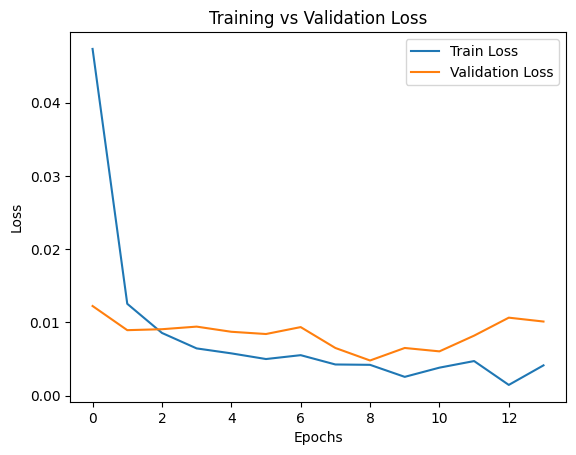

In [18]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')

plt.legend()
plt.show()

In [36]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing import image

img_path = "/content/dataset/leaf/leaf_image0125.jpg"

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

In [37]:
prediction = model.predict(img_array)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
[[0.0060065]]


In [38]:
if prediction[0][0] < 0.5:
    print("Leaf")
else:
    print("Not Leaf")

Leaf


Model is ready for predicting leaf vs nonleaf